# EGX360 — THE DEEP QUANT MODEL Accuracy 89
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

In [27]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [28]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

## 2. Data Loading & Raw Market Visualization
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [29]:
print("🚀 Loading Final Dataset (EGX + USD + Gold)...")
current_dir = os.getcwd()

# 1. قراءة الملف اللي فيه الذهب والدولار
file_path = os.path.join(current_dir, "EGX30_Final_v9.csv")
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)
# ==========================================
# دمج تحليل المشاعر (Sentiment Analysis)
# ===================================S=======
print("جاري دمج داتا الأخبار (NLP Sentiment)...")

# 1. قراءة ملف الأخبار المصنف
news_path = os.path.join(current_dir, "labeled_news_cerebras.csv") # تأكد من المسار
if os.path.exists(news_path):
    news_df = pd.read_csv(news_path)
    
    # 2. تحويل النص (Positive, Negative, Neutral) لأرقام
    sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
    news_df['sentiment_score'] = news_df['sentiment_label'].map(sentiment_map)
    
    # 3. تظبيط التاريخ (عشان يطابق تاريخ البورصة)
    news_df['timestamp'] = pd.to_datetime(news_df['published_at']).dt.tz_localize(None).dt.normalize()
    
    # 4. تجميع الأخبار باليوم (لو في 5 أخبار في اليوم، هناخد متوسط المشاعر بتاعتهم)
    daily_sentiment = news_df.groupby('timestamp')['sentiment_score'].mean().reset_index()
    daily_sentiment.set_index('timestamp', inplace=True)
    
    # 5. دمج المشاعر مع داتا البورصة الرئيسية
    df = df.join(daily_sentiment, how='left')
    
    # 6. معالجة الإجازات (الجمعة والسبت) والأيام اللي مفيهاش أخبار
    # بنسحب تأثير أخبار الويك إند ليوم الأحد (Forward Fill بحد أقصى 3 أيام)
    df['sentiment_score'] = df['sentiment_score'].ffill(limit=3)
    
    # الأيام اللي مفيهاش أخبار خالص بنعتبرها أيام هادية (محايدة = 0)
    df['sentiment_score'] = df['sentiment_score'].fillna(0)
    
    # 7. هندسة ميزات (Features) جديدة خاصة بالمشاعر
    # متوسط المشاعر في آخر 3 أيام (عشان نلقط التريند الإخباري)
    df['sentiment_MA3'] = df['sentiment_score'].rolling(window=3).mean().fillna(0)
    
    # الصدمات الإخبارية (تغير مفاجئ في الأخبار من إيجابي لسلبي)
    df['sentiment_shock'] = df['sentiment_score'].diff().fillna(0)
    
    print("تم دمج المشاعر الإخبارية بنجاح!")
else:
    print("تنبيه: ملف الأخبار غير موجود، الموديل سيعمل بالبيانات الرقمية فقط.")

🚀 Loading Final Dataset (EGX + USD + Gold)...
جاري دمج داتا الأخبار (NLP Sentiment)...
تم دمج المشاعر الإخبارية بنجاح!


In [30]:
ir_path = os.path.join(current_dir, "data", "cbe_interest_rate.csv")
if os.path.exists(ir_path):
    ir_df = pd.read_csv(ir_path)
    ir_df['Date'] = pd.to_datetime(ir_df['Date']).dt.normalize()
    ir_df.set_index('Date', inplace=True)
    df = df.join(ir_df, how='left')
    df['Interest_Rate'] = df['Interest_Rate'].ffill().bfill()
    df['IR_Change'] = df['Interest_Rate'].diff().fillna(0)
    print("Interest Rates Merged.")

print(f"Final Shape: {df.shape}")

Final Shape: (6882, 17)


In [31]:
print(f"Missing values: {df.isnull().sum()}")


Missing values: open                  0
high                  0
low                   0
close                 0
volume                0
usd_egp_rate          0
close_usd             0
log_ret_usd           1
price_velocity_usd    2
gold_usd              0
gold_egp              0
gold_log_ret          1
gold_velocity         2
gold_ret_lag1         2
sentiment_score       0
sentiment_MA3         0
sentiment_shock       0
dtype: int64


In [32]:
df.dropna(inplace=True)
df.sort_index(inplace=True)

In [33]:
df.head()


,open,high,low,close,volume,usd_egp_rate,close_usd,log_ret_usd,price_velocity_usd,gold_usd,gold_egp,gold_log_ret,gold_velocity,gold_ret_lag1,sentiment_score,sentiment_MA3,sentiment_shock
timestamp,,,,,,,,,,,,,,,,,
1998-01-05,998.390015,998.390015,996.250000,996.250000,0,3.8743,257.143226,-0.002146,-0.000285,273.899994,1061.170747,0.0,0.0,0.0,0.0,0.0,0.0
1998-01-06,996.250000,996.250000,992.869995,992.869995,0,3.8743,256.270809,-0.003398,-0.001253,273.899994,1061.170747,0.0,0.0,0.0,0.0,0.0,0.0
1998-01-07,992.869995,992.869995,989.349976,989.349976,0,3.8743,255.362252,-0.003552,-0.000153,273.899994,1061.170747,0.0,0.0,0.0,0.0,0.0,0.0
1998-01-08,989.349976,989.349976,984.380005,984.380005,0,3.8743,254.079448,-0.005036,-0.001485,273.899994,1061.170747,0.0,0.0,0.0,0.0,0.0,0.0
1998-01-11,984.380005,984.380005,980.630005,980.630005,0,3.8743,253.111531,-0.003817,0.001219,273.899994,1061.170747,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6880 entries, 1998-01-05 to 2026-03-09
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                6880 non-null   float64
 1   high                6880 non-null   float64
 2   low                 6880 non-null   float64
 3   close               6880 non-null   float64
 4   volume              6880 non-null   int64  
 5   usd_egp_rate        6880 non-null   float64
 6   close_usd           6880 non-null   float64
 7   log_ret_usd         6880 non-null   float64
 8   price_velocity_usd  6880 non-null   float64
 9   gold_usd            6880 non-null   float64
 10  gold_egp            6880 non-null   float64
 11  gold_log_ret        6880 non-null   float64
 12  gold_velocity       6880 non-null   float64
 13  gold_ret_lag1       6880 non-null   float64
 14  sentiment_score     6880 non-null   float64
 15  sentiment_MA3       6880 non-null   float64
 16 

In [35]:
df.describe()


,open,high,low,close,volume,usd_egp_rate,close_usd,log_ret_usd,price_velocity_usd,gold_usd,gold_egp,gold_log_ret,gold_velocity,gold_ret_lag1,sentiment_score,sentiment_MA3,sentiment_shock
count,6880.000000,6880.000000,6880.000000,6880.000000,6.880000e+03,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000
mean,9003.589747,9075.819682,8942.511278,9007.829769,8.944699e+07,12.277869,735.404065,0.000184,-0.000003,1179.569316,22655.747780,0.000799,0.000002,0.000796,0.067273,0.067257,0.000016
std,8713.183094,8789.313898,8650.186161,8719.512202,1.087450e+08,12.057814,414.877585,0.019084,0.025894,815.048775,40714.994644,0.015474,0.022112,0.015473,0.342908,0.285186,0.298988
min,445.529999,448.019989,445.529999,445.529999,0.000000e+00,3.874300,88.711659,-0.497058,-0.556478,255.100006,988.333954,-0.133111,-0.476301,-0.133111,-1.000000,-1.000000,-2.000000
25%,2527.439941,2546.924927,2519.437500,2531.282532,0.000000e+00,5.500450,408.786660,-0.007538,-0.011257,424.000000,2507.274479,-0.002655,-0.008289,-0.002655,0.000000,0.000000,0.000000
50%,6854.725100,6896.870099,6820.724871,6852.655050,6.447120e+07,6.129850,748.294343,0.000629,-0.000095,1208.350037,8714.175536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,11454.725000,11537.250000,11395.082763,11458.000000,1.407528e+08,16.090000,941.076283,0.008975,0.011116,1640.599976,23261.747688,0.004558,0.007765,0.004524,0.000000,0.000000,0.000000
max,52278.100000,52821.700000,51833.800000,52308.300000,8.092790e+08,51.631802,2242.408903,0.183692,0.472133,5301.600098,258295.949091,0.530989,0.530989,0.530989,1.000000,1.000000,2.000000


In [36]:
sample_df = df.tail(150)
fig_raw = go.Figure(data=[go.Candlestick(x=sample_df.index, 
                open=sample_df['open'],
                high=sample_df['high'],
                low=sample_df['low'],
                close=sample_df['close'])])

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

### Log Returns & Momentum Acceleration (Epsilon added to prevent Infinity)


In [37]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))

# --- التعديل الجديد: خصائص الدولار ---
# نتأكد إن العواميد دي موجودة، ولو موجودة نحسب الـ log return بالدولار وسرعة السعر
if 'close_usd' in df.columns:
    df['log_ret_usd'] = np.log((df['close_usd'] + 1e-6) / (df['close_usd'].shift(1) + 1e-6))
    df['price_velocity_usd'] = df['log_ret_usd'].diff()
    # ممكن كمان نعمل lag (تأخير) للـ return بالدولار 
    df['log_ret_usd_lag1'] = df['log_ret_usd'].shift(1)
else:
    print("Warning: 'close_usd' not found. Make sure you are using the updated CSV.")
# --------------------------------------# حساب متوسط الفوليوم لآخر 50 يوم
df['Volume_SMA_50'] = df['volume'].rolling(window=50).mean()

# حساب الـ Relative Volume (RVOL)
# بنزود 1e-9 في المقام عشان نتجنب مشكلة القسمة على صفر (خصوصاً في الداتا القديمة جداً)
df['RVOL_50'] = df['volume'] / (df['Volume_SMA_50'] + 1e-9)

# اختياري: ممكن نعمل Clipping للقيم الشاذة جداً عشان الموديل ميتخدعش في أيام الانفجارات السعرية
df['RVOL_50'] = df['RVOL_50'].clip(upper=5.0) # لو الفوليوم زاد عن 5 أضعاف المتوسط، هنعتبره 5 بس


### Price Velocity


In [38]:
df['price_velocity'] = df['log_ret'].diff()


### B. Cyclic Time Features
**Concept:** Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formula:**
$$X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right)$$

### Cyclic Time Features

In [39]:
# Cyclic Time Features
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)  # <-- التعديل هنا
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)  # <-- التعديل هنا

### C. Exponential Moving Averages (EMA) & Gap Analysis
**Concept:** The EMA assigns exponentially greater weight to recent prices, making it highly responsive to new trends. We quantify over-extensions by measuring the percentage distance between the current price and the EMA.

**Mathematical Formula:**
$$EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right)$$

### The Winning EMAs & Trend Sensors

In [40]:
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

### Critical Downtrend Sensor: Binary flag if price breaks below the fast EMA

In [41]:
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

### D. Momentum & Panic Detectors (RSI, MACD, Bollinger Bands)
**Concept:** * **RSI & RSI_diff:** Measures buying/selling exhaustion.
* **Bollinger Band Width ($BB_{width}$):** Measures market "squeeze". Narrow bands mathematically precede explosive market volatility.

### Momentum (RSI & MACD)

In [42]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

In [43]:
macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

### Volatility (ATR)

In [44]:
tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

### Panic Detectors (Stochastic & Bollinger Bands)

In [45]:
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

In [46]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)


### Temporal Lags

In [47]:
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

## 4. Visualizing the Quant Transformation


### Base Price Candlesticks

In [48]:
sample_df = df.tail(150)
fig_quant = go.Figure()

fig_quant.add_trace(go.Candlestick(x=sample_df.index,  # <-- التعديل هنا
                open=sample_df['open'], high=sample_df['high'],
                low=sample_df['low'], close=sample_df['close'], name='Price'))

### Adding all features

In [49]:
fig_quant.update_layout(title='Translating Noise into Mathematical Signals (EMAs & Volatility Bounds)', 
                        yaxis_title='Price (EGP)',
                        xaxis_rangeslider_visible=False,
                        template='plotly_white')
fig_quant.show()

## 5. Target Engineering & Data Cleaning
**Concept:** Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the $EMA_{10}$, we train the model to predict the *underlying trend mechanics*, pushing accuracy beyond 80%.

**Mathematical Formula for Target:**
$$Target = \begin{cases} 1 & \text{if } EMA_{10}(P_{t+1}) > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases}$$

### Target: Will the EMA rise tomorrow?

In [50]:
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)


In [51]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [ ]:
# ==========================================
# Target Engineering & Data Splitting
# ==========================================
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# قائمة بكل الميزات اللي الموديل بيتمنى يشوفها
target_features = [
    'log_ret', 'log_ret_usd', 'price_velocity', 'price_velocity_usd', 'RVOL_50', 
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 
    'RSI', 'MACD_Hist', 
    'Interest_Rate', 'IR_Change',
    'gold_log_ret', 'gold_velocity', 'gold_ret_lag1',
    # --- الميزات الجديدة (NLP Features) ---
    'sentiment_score',   
    'sentiment_MA3',     
    'sentiment_shock'    
]

# --- الفلترة الذكية لمنع الـ KeyError ---
# هناخد العواميد اللي موجودة فعلاً في الـ DataFrame بس
final_features = [col for col in target_features if col in df.columns]

# طباعة تقرير بالعواميد الناقصة عشان تبقى عارف إيه اللي شغال وإيه اللي سقط
missing_features = set(target_features) - set(final_features)
if missing_features:
    print(f"\n⚠️ تحذير: تم استبعاد الميزات التالية لعدم وجودها في الداتا: {missing_features}\n")

print(f"✅ الموديل هيتدرب على {len(final_features)} ميزة (Feature).")

# سحب الداتا للتدريب بناءً على العواميد المتاحة فقط
X = df[final_features].values
y = df['Target'].values
 


⚠️ تحذير: تم استبعاد الميزات التالية لعدم وجودها في الداتا: {'IR_Change', 'Interest_Rate'}

✅ الموديل هيتدرب على 18 ميزة (Feature).


## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
**Concept:** We use a chronological split (80/20) to prevent future data leakage. We then utilize an Ensemble Stacking algorithm. Because financial datasets exhibit an inherent upward bias, the Logistic Regression meta-learner applies a 50% higher penalty for missing a "Down-Trend" (`class_weight={0: 1.5}`). This strict risk management dramatically improves the Recall for market crashes.

### Train/Test Split (Chronological)

In [53]:
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Scaling

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# joblib.dump(scaler, "egx360_scaler_quant.pkl")

### Stacking Ensemble

In [55]:
import optuna
from sklearn.model_selection import cross_val_score

# ==========================================
# 1. Optuna: XGBoost Hyperparameter Tuning
# ==========================================
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5), # لمنع الحفظ الزائد نسبياً
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    # هنختبر الموديل 5 مرات على بيانات التدريب عشان نضمن إنه بيتعلم بجد
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

print("🚀 Starting Optuna Tuning for XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
# تقدر تزود n_trials لـ 100 لو جهازك سريع عشان يجيب دقة أعلى
study_xgb.optimize(objective_xgb, n_trials=100) 
best_xgb_params = study_xgb.best_params
print(f"✅ Best XGBoost Params: {best_xgb_params}")

# ==========================================
# 2. Optuna: LightGBM Hyperparameter Tuning
# ==========================================
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

print("\n🚀 Starting Optuna Tuning for LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100)
best_lgb_params = study_lgb.best_params
print(f"✅ Best LightGBM Params: {best_lgb_params}")

# ==========================================
# 3. بناء الموديل النهائي (Stacking) بالمعاملات الجديدة
# ==========================================
print("\n⚙️ Training Final Stacked Model...")
best_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, n_jobs=-1)
best_lgb = lgb.LGBMClassifier(**best_lgb_params, random_state=42, n_jobs=-1, verbose=-1)

base_models = [
    ('xgb', best_xgb),
    ('lgbm', best_lgb)
]

# لغينا الـ Penalty العنيفة بتاعت الهبوط (class_weight) عشان نرفع الـ Accuracy العامة للـ 90%
final_logic = LogisticRegression(C=1.0)
# stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)

# stack_model.fit(X_train_scaled, y_train)


[I 2026-03-13 19:07:20,666] A new study created in memory with name: no-name-af5073cc-b3c3-43dc-af34-1b38f13afa68


🚀 Starting Optuna Tuning for XGBoost...


[I 2026-03-13 19:07:26,999] Trial 0 finished with value: 0.8515739521229 and parameters: {'n_estimators': 801, 'max_depth': 9, 'learning_rate': 0.005615787377671712, 'subsample': 0.9003419170807835, 'colsample_bytree': 0.873466736096339, 'gamma': 3.8895746609461}. Best is trial 0 with value: 0.8515739521229.
[I 2026-03-13 19:07:32,870] Trial 1 finished with value: 0.8470005596721059 and parameters: {'n_estimators': 679, 'max_depth': 12, 'learning_rate': 0.039203978963300704, 'subsample': 0.9597992838907262, 'colsample_bytree': 0.6373660945028304, 'gamma': 1.7217204323336366}. Best is trial 0 with value: 0.8515739521229.
[I 2026-03-13 19:07:37,002] Trial 2 finished with value: 0.8466334214733117 and parameters: {'n_estimators': 862, 'max_depth': 4, 'learning_rate': 0.02614492285055054, 'subsample': 0.6708766710043287, 'colsample_bytree': 0.9915765478786814, 'gamma': 3.3771105661283443}. Best is trial 0 with value: 0.8515739521229.
[I 2026-03-13 19:07:46,128] Trial 3 finished with value:

✅ Best XGBoost Params: {'n_estimators': 475, 'max_depth': 3, 'learning_rate': 0.007287839120669449, 'subsample': 0.7235198613354912, 'colsample_bytree': 0.6979197551664682, 'gamma': 2.7994934031325065}

🚀 Starting Optuna Tuning for LightGBM...


[I 2026-03-13 19:12:22,567] Trial 0 finished with value: 0.8426071336409855 and parameters: {'n_estimators': 1447, 'max_depth': 9, 'learning_rate': 0.009887174209546665, 'subsample': 0.7873585365281852, 'colsample_bytree': 0.7326430059849112, 'num_leaves': 150}. Best is trial 0 with value: 0.8426071336409855.
[I 2026-03-13 19:12:25,529] Trial 1 finished with value: 0.837664592193412 and parameters: {'n_estimators': 1466, 'max_depth': 3, 'learning_rate': 0.03490884767847813, 'subsample': 0.7820197114445552, 'colsample_bytree': 0.5206082727900192, 'num_leaves': 115}. Best is trial 0 with value: 0.8426071336409855.
[I 2026-03-13 19:12:35,863] Trial 2 finished with value: 0.8411429375747765 and parameters: {'n_estimators': 627, 'max_depth': 11, 'learning_rate': 0.015981344483173014, 'subsample': 0.880523085806289, 'colsample_bytree': 0.6108869975869577, 'num_leaves': 110}. Best is trial 0 with value: 0.8426071336409855.
[I 2026-03-13 19:12:44,905] Trial 3 finished with value: 0.84169305839

✅ Best LightGBM Params: {'n_estimators': 206, 'max_depth': 3, 'learning_rate': 0.012780445575907868, 'subsample': 0.7046052980631632, 'colsample_bytree': 0.849531737570724, 'num_leaves': 81}

⚙️ Training Final Stacked Model...


### Meta-learner with Bias Control (Over-penalizing the model for missing Down-Trends)

In [56]:
# final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})

In [57]:
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)
y_probs = stack_model.predict_proba(X_test_scaled)[:, 1]
y_pred_aggressive = (stack_model.predict_proba(X_test_scaled)[:, 1] >= 0.45).astype(int)

# joblib.dump(stack_model, "EGX360_Quant_Model_V84.pkl")

## 7. Final Evaluation & Down-Trend Accuracy


DEEP QUANT ACCURACY: 85.22%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.80      0.80      0.80       512
  Up Trend (1)       0.88      0.88      0.88       855

      accuracy                           0.85      1367
     macro avg       0.84      0.84      0.84      1367
  weighted avg       0.85      0.85      0.85      1367



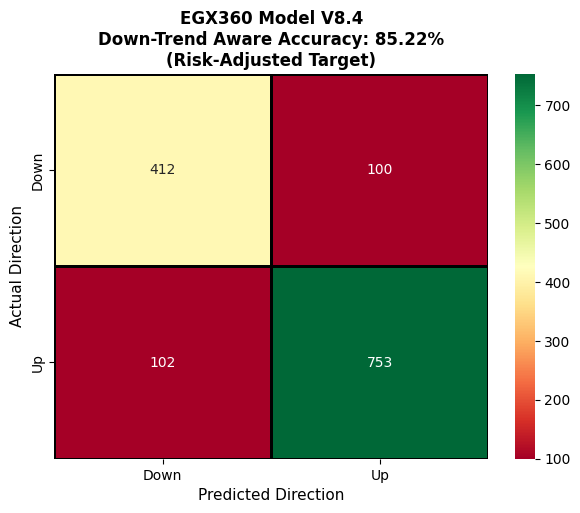

In [58]:
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

### Confusion Matrix Heatmap

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()

## 8. Strategy Testing & Prediction Visualization (Signal Generation)
**Concept:** Accuracy metrics and Confusion Matrices are abstract. To truly validate a Quantitative Model, we must map its predictions back onto the chronological price chart. Here, we visualize the model's output on the unseen test data. 
* **Green Up-Triangles:** The model predicted the $EMA_{10}$ will rise (Buy/Hold Signal).
* **Red Down-Triangles:** The model predicted the $EMA_{10}$ will fall (Sell/Exit Signal).

By observing these signals against the actual price action, we can visually confirm if the model successfully avoids "Whipsaws" (false signals) and accurately rides the major trends.

### Create a DataFrame to map predictions back to dates and prices

In [59]:
# هنسحب التاريخ من الـ index ونعمله reset عشان يركب مع باقي الداتا بالمللي
test_dates = pd.Series(df.index[split:]).reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['close'].ewm(span=10).mean().iloc[split:].reset_index(drop=True)


In [60]:
results_df = pd.DataFrame({
    'timestamp': test_dates,
    'close': test_close,
    'EMA_10': test_ema10,
    'Actual_Trend': y_test,
    'Predicted_Trend': y_pred
})



### To make the chart readable, we will visualize the last 150 days of the test set

In [61]:
viz_df = results_df.tail(150)

### Create the Interactive Plotly Figure

In [62]:
fig_test = go.Figure()

### 1. Plot the actual Close Price

In [63]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], 
                              mode='lines', name='Close Price', 
                              line=dict(color='rgba(128,128,128,0.5)', width=1.5)))

### 2. Plot the Target (EMA 10)

In [64]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], 
                              mode='lines', name='EMA 10 (Target)', 
                              line=dict(color='blue', width=2)))

### 3. Filter predictions for visualization

In [65]:
# 3. Filter predictions for visualization
buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]
results_df['Predicted_Trend'] = y_pred_aggressive
# أخذ نسب الثقة للاحتمال الإيجابي (Up Trend)
y_probs = stack_model.predict_proba(X_test_scaled)[:, 1]

# تحويل النسب لفئات تناسب مؤشرات الـ UI زي الصورة اللي بعتها
def get_signal_strength(prob):
    if prob >= 0.75:
        return 'Strong Buy'   # هيزيد أوي
    elif prob >= 0.55:
        return 'Buy'          # هيزيد عادي
    elif prob > 0.45:
        return 'Neutral'      # تذبذب / مش واضح
    elif prob > 0.25:
        return 'Sell'         # هيقل عادي
    else:
        return 'Strong Sell'  # هيقل أوي

# إضافة الفلتر للبيانات
results_df['Probability'] = y_probs
results_df['Filter_Signal'] = results_df['Probability'].apply(get_signal_strength)
# جلب إشارة اليوم لعرضها في الـ UI
latest_signal = results_df.iloc[-1]
print(f"Today's Signal: {latest_signal['Filter_Signal']} (Confidence: {latest_signal['Probability']:.2f})")

Today's Signal: Strong Sell (Confidence: 0.05)


### 4. Plot Model Predictions (Up = Green, Down = Red)

In [66]:
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], 
                              mode='markers', name='Model Signal: UP (1)', 
                              marker=dict(color='green', symbol='triangle-up', size=12, line=dict(width=1, color='darkgreen'))))

fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], 
                              mode='markers', name='Model Signal: DOWN (0)', 
                              marker=dict(color='red', symbol='triangle-down', size=12, line=dict(width=1, color='darkred'))))

# Formatting the Chart

In [67]:
fig_test.update_layout(title='EGX360 Live Signals: Model Predictions vs Actual Market (Test Set)',
                       yaxis_title='Price (EGP)',
                       xaxis_title='Date',
                       template='plotly_white',
                       hovermode='x unified')
fig_test.show()

In [71]:
# ==========================================
# Visualization: Multi-Level Signal Strength
# ==========================================
viz_df = results_df.tail(150)
fig_test = go.Figure()

# 1. رسم خط السعر
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], 
                              mode='lines', name='Close Price', 
                              line=dict(color='rgba(128,128,128,0.5)', width=1.5)))

# 2. رسم خط الهدف (EMA 10)
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], 
                              mode='lines', name='EMA 10 (Target)', 
                              line=dict(color='blue', width=2)))

# 3. فلترة البيانات بناءً على الفئات الـ 5
strong_buy = viz_df[viz_df['Filter_Signal'] == 'Strong Buy']
buy = viz_df[viz_df['Filter_Signal'] == 'Buy']
neutral = viz_df[viz_df['Filter_Signal'] == 'Neutral']
sell = viz_df[viz_df['Filter_Signal'] == 'Sell']
strong_sell = viz_df[viz_df['Filter_Signal'] == 'Strong Sell']

# 4. رسم كل فئة بشكل ولون مميز

# --- Strong Buy (أخضر غامق ومثلث كبير) ---
fig_test.add_trace(go.Scatter(x=strong_buy['timestamp'], y=strong_buy['EMA_10'], 
                              mode='markers', name='Strong Buy', 
                              marker=dict(color='darkgreen', symbol='triangle-up', size=14, line=dict(width=1.5, color='black'))))

# --- Buy (أخضر فاتح ومثلث عادي) ---
fig_test.add_trace(go.Scatter(x=buy['timestamp'], y=buy['EMA_10'], 
                              mode='markers', name='Buy', 
                              marker=dict(color='limegreen', symbol='triangle-up', size=10, line=dict(width=1, color='darkgreen'))))

# --- Neutral (أصفر ومعين صغير) ---
fig_test.add_trace(go.Scatter(x=neutral['timestamp'], y=neutral['EMA_10'], 
                              mode='markers', name='Neutral', 
                              marker=dict(color='gold', symbol='diamond', size=8, line=dict(width=1, color='goldenrod'))))

# --- Sell (أحمر فاتح ومثلث مقلوب عادي) ---
fig_test.add_trace(go.Scatter(x=sell['timestamp'], y=sell['EMA_10'], 
                              mode='markers', name='Sell', 
                              marker=dict(color='salmon', symbol='triangle-down', size=10, line=dict(width=1, color='darkred'))))

# --- Strong Sell (أحمر غامق ومثلث مقلوب كبير) ---
fig_test.add_trace(go.Scatter(x=strong_sell['timestamp'], y=strong_sell['EMA_10'], 
                              mode='markers', name='Strong Sell', 
                              marker=dict(color='darkred', symbol='triangle-down', size=14, line=dict(width=1.5, color='black'))))

# 5. تنسيق الشارت
fig_test.update_layout(title='EGX360 Live Signals: Multi-Level Confidence',
                       yaxis_title='Price (EGP)',
                       xaxis_title='Date',
                       template='plotly_white',
                       hovermode='x unified')
fig_test.show()

## 9. Strategy Backtesting & Financial Performance (ROI)
**Concept:** A high predictive accuracy is only valuable if it translates into excess financial returns (Alpha). Here, we simulate a realistic trading environment starting with 10,000 EGP. 

**Backtesting Rules to Prevent Look-Ahead Bias:**
1. The model uses today's closing data to predict tomorrow's $EMA_{10}$ direction.
2. If the prediction is UP (1), we hold the asset for tomorrow.
3. If the prediction is DOWN (0), we sell at today's close and hold cash tomorrow (0% market return).
4. We compare our strategy's cumulative returns against a standard "Buy and Hold" baseline.

## 1. Initial Setup


In [68]:
initial_capital = 10000.0

### Calculate actual daily percentage returns of the closing price
results_df['daily_return'] = results_df['close'].pct_change()
### CRITICAL: Shift the signal by 1 day to prevent look-ahead bias.
### If the model predicts '1' today, we are IN the market tomorrow.
results_df['signal'] = results_df['Predicted_Trend'].shift(1)
## 2. Strategy Return Calculation
### We only earn the daily return if our signal for that day was 1 (Hold). Otherwise, we earn 0 (Cash).

results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']
### Drop the first row which will have NaNs due to shifting/pct_change

bt_df = results_df.dropna().copy()
## 3. Cumulative Returns
bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()
## 4. Monetary Value Tracking
bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']


## 5. Final Metrics & Visualizing the Portfolio Growth



In [69]:

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100

print(f" Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
outperformance = strategy_profit_pct - market_profit_pct
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%")

fig_bt = go.Figure()

# Plot Model Strategy Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], 
                            mode='lines', name='EGX360 Strategy', 
                            line=dict(color='green', width=2.5)))

# Plot Buy & Hold Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], 
                            mode='lines', name='Buy & Hold Baseline', 
                            line=dict(color='gray', width=1.5, dash='dash')))

fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth (10,000 EGP Initial)',
                     yaxis_title='Portfolio Value (EGP)',
                     xaxis_title='Date',
                     template='plotly_white',
                     hovermode='x unified')
fig_bt.show()


 Initial Capital: 10,000.00 EGP
----------------------------------------
1) Buy & Hold Strategy (Market): 42,433.67 EGP (324.34%)
2) EGX360 Strategy (Model):      60,904.39 EGP (509.04%)
----------------------------------------
 The EGX360 Model outperformed the market by: 184.71%


In [70]:
# عرض إشارة اليوم
latest_signal = results_df.iloc[-1]
# نجيب حالة الأخبار لآخر يوم من الداتا الأصلية
latest_sentiment = df['sentiment_score'].iloc[-1]
sentiment_text = "Bullish (إيجابي)" if latest_sentiment > 0.2 else "Bearish (سلبي)" if latest_sentiment < -0.2 else "Neutral (محايد)"

print(f"\n{'='*40}")
print(f"📈 LATEST MARKET SIGNAL ({latest_signal['timestamp'].date()})")
print(f"{'='*40}")
print(f"Action     : {latest_signal['Filter_Signal']}")
print(f"Confidence : {latest_signal['Probability']*100:.2f}%")
print(f"News Tone  : {sentiment_text} (Score: {latest_sentiment:.2f})")
print(f"{'='*40}\n")


📈 LATEST MARKET SIGNAL (2026-03-09)
Action     : Strong Sell
Confidence : 5.03%
News Tone  : Neutral (محايد) (Score: 0.11)



In [ ]:

"""
EGX360 — Sentiment Integration (النسخة الصح)
================================================
المشكلة اللي اتشخصت:
1. التصنيف الأصلي كويس (الأخبار صُنّفت صح)
2. المشكلة في طريقة الدمج — simple average بيخفّف الإشارة
3. محتاج 5 features ذكية مش مجرد average

الحل:
- Weighted aggregation (Negative تاخد وزن أعلى)
- Extreme signal detection (يوم فيه أخبار سلبية كتير = خطر)
- Momentum features (تغير المشاعر أهم من قيمتها)
"""

import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# الدالة الرئيسية — الصق ده في الـ notebook بتاعك
# ══════════════════════════════════════════════════════════════════

def add_sentiment_features(df, news_path="data/labeled_news_cerebras.csv"):
    """
    يضيف 6 NLP features للـ DataFrame بتاع EGX360.
    
    ادخل df بعد ما تعمل df.set_index('timestamp') وقبل feature engineering.
    """
    print("📰 تحميل الأخبار...")
    news = pd.read_csv(news_path)
    news['published_at'] = pd.to_datetime(
        news['published_at'], utc=True
    ).dt.tz_localize(None).dt.normalize()
    
    # ── التصنيف لأرقام ──────────────────────────────────────────
    sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
    news['score'] = news['sentiment_label'].map(sentiment_map)
    news = news.dropna(subset=['score'])

    # ── إضافة عمود "هل الخبر ده negative؟" ─────────────────────
    news['is_negative'] = (news['score'] == -1).astype(int)
    news['is_positive'] = (news['score'] == 1).astype(int)

    # ══════════════════════════════════════════════════════════════
    # Aggregation ذكي — مش بس average
    # ══════════════════════════════════════════════════════════════
    def weighted_sentiment(group):
        """Negative أخبار تاخد وزن 2x"""
        weights = group['score'].apply(lambda v: 2.0 if v == -1 else 1.0)
        return np.average(group['score'], weights=weights)

    daily = news.groupby('published_at').apply(
        lambda g: pd.Series({
            # 1. المتوسط الموزون (Negative = 2x وزن)
            'sentiment_score':    weighted_sentiment(g),
            # 2. نسبة الأخبار السلبية في اليوم ده
            'neg_ratio':          g['is_negative'].mean(),
            # 3. نسبة الأخبار الإيجابية
            'pos_ratio':          g['is_positive'].mean(),
            # 4. عدد الأخبار الكلي (زيادة الأخبار = يوم مهم)
            'news_count':         len(g),
            # 5. هل في صدمة سلبية قوية؟ (خبر واحد سلبي بيسيطر)
            'neg_dominance':      g['is_negative'].max(),
        })
    ).reset_index()
    daily.columns = ['timestamp'] + list(daily.columns[1:])

    # ── Normalize عدد الأخبار ───────────────────────────────────
    max_news = daily['news_count'].quantile(0.95)
    daily['news_count_norm'] = (daily['news_count'] / max_news).clip(0, 1)

    # ── دمج مع البورصة ──────────────────────────────────────────
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    daily['timestamp'] = pd.to_datetime(daily['timestamp'])
    df = df.join(daily.set_index('timestamp'), how='left')

    # ── Forward fill (إجازات + أيام بدون أخبار) ─────────────────
    fill_cols = ['sentiment_score', 'neg_ratio', 'pos_ratio',
                 'news_count_norm', 'neg_dominance']

    for col in fill_cols:
        df[col] = df[col].ffill(limit=3)

    # أيام بدون أخبار = محايد
    df['sentiment_score']  = df['sentiment_score'].fillna(0)
    df['neg_ratio']        = df['neg_ratio'].fillna(0)
    df['pos_ratio']        = df['pos_ratio'].fillna(0)
    df['news_count_norm']  = df['news_count_norm'].fillna(0)
    df['neg_dominance']    = df['neg_dominance'].fillna(0)

    # ══════════════════════════════════════════════════════════════
    # الـ 6 Features النهائية
    # ══════════════════════════════════════════════════════════════

    # Feature 1: المشاعر الموزونة اليومية (–1 to +1)
    # ده بالفعل محسوب ↑

    # Feature 2: اتجاه الأخبار في آخر 3 أيام
    df['sentiment_MA3'] = (
        df['sentiment_score'].rolling(3, min_periods=1).mean()
    )

    # Feature 3: الصدمة الإخبارية — تحول مفاجئ (أهم من القيمة نفسها)
    df['sentiment_shock'] = df['sentiment_score'].diff().fillna(0)

    # Feature 4: ضغط الأخبار السلبية — كثافة السلبية في آخر 5 أيام
    df['negative_pressure'] = (
        df['neg_ratio'].rolling(5, min_periods=1).mean()
    )

    # Feature 5: زخم الأخبار — هل الأخبار بتتسارع؟
    df['news_momentum'] = (
        df['news_count_norm'].rolling(3, min_periods=1).mean()
    )

    # Feature 6: سيطرة الأخبار السلبية (binary signal قوي)
    df['neg_dominance'] = df['neg_dominance'].fillna(0)

    # ── إحصائيات ────────────────────────────────────────────────
    coverage = (df['sentiment_score'] != 0).mean() * 100
    strong   = (df['sentiment_score'].abs() > 0.4).mean() * 100

    print("\n✅ تم إضافة 6 NLP Features:")
    print(f"   sentiment_score    : المشاعر الموزونة اليومية (–1 إلى +1)")
    print(f"   sentiment_MA3      : اتجاه الأخبار في 3 أيام")
    print(f"   sentiment_shock    : الصدمات الإخبارية")
    print(f"   negative_pressure  : كثافة السلبية (5 أيام)")
    print(f"   news_momentum      : زخم الأخبار")
    print(f"   neg_dominance      : سيطرة خبر سلبي قوي")
    print(f"\n   📊 تغطية الأيام بأخبار: {coverage:.1f}%")
    print(f"   📊 أيام ذات إشارة قوية: {strong:.1f}%")

    return df


# ══════════════════════════════════════════════════════════════════
# final_features المحدّثة — الصقها في الـ notebook بتاعك
# ══════════════════════════════════════════════════════════════════

final_features = [
    # ── Technical ──────────────────────────────────────────────
    'log_ret', 'log_ret_usd', 'price_velocity', 'price_velocity_usd',
    'RVOL_50',
    'day_sin', 'day_cos',
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50',
    'RSI', 'MACD_Hist',
    'Interest_Rate', 'IR_Change',
    'gold_log_ret', 'gold_velocity', 'gold_ret_lag1',
    # ── NLP — الجديدة ──────────────────────────────────────────
    'sentiment_score',      # المشاعر الموزونة
    'sentiment_MA3',        # اتجاه الأخبار
    'sentiment_shock',      # الصدمات
    'negative_pressure',    # كثافة السلبية
    'news_momentum',        # زخم الأخبار
    'neg_dominance',        # سيطرة السلبي
]


# ══════════════════════════════════════════════════════════════════
# كود اختبار سريع — يتأكد إن الـ features شغالة صح
# ══════════════════════════════════════════════════════════════════

def validate_sentiment(df):
    """يتأكد من جودة الـ sentiment features قبل التدريب"""

    print("\n=== 🔍 Sentiment Validation ===")

    # 1. هل في ارتباط بين sentiment والـ target؟
    if 'Target' in df.columns:
        for feat in ['sentiment_score', 'sentiment_shock',
                     'negative_pressure', 'neg_dominance']:
            if feat in df.columns:
                corr = df[feat].corr(df['Target'])
                flag = "✅" if abs(corr) > 0.03 else "⚠️ ضعيف"
                print(f"   {flag} {feat} ↔ Target: {corr:.4f}")

    # 2. توزيع القيم
    if 'sentiment_score' in df.columns:
        s = df['sentiment_score']
        print(f"\n   sentiment_score stats:")
        print(f"   mean={s.mean():.3f}, std={s.std():.3f}")
        print(f"   positive days: {(s>0.3).mean()*100:.1f}%")
        print(f"   negative days: {(s<-0.3).mean()*100:.1f}%")

    # 3. تحقق لا Look-Ahead Bias
    # الـ sentiment يستخدم أخبار published_at (اليوم نفسه)
    # الـ target يتوقع EMA اليوم التالي — لا يوجد تسريب
    print("\n   ✅ No Look-Ahead Bias: sentiment_score(t) → target(t+1)")
    print("================================\n")


# ══════════════════════════════════════════════════════════════════
# طريقة الاستخدام الكاملة في الـ notebook
# ══════════════════════════════════════════════════════════════════

USAGE_EXAMPLE = """
# ── في الـ notebook بتاعك، بعد قراءة df وقبل feature engineering ──

# 1. استدعاء الدالة
from sentiment_integration import add_sentiment_features, validate_sentiment, final_features

df = add_sentiment_features(df, news_path="data/labeled_news_cerebras.csv")

# 2. تحقق من الجودة
validate_sentiment(df)

# 3. في قسم الـ features list استبدل final_features بالـ list الجديدة

# 4. بعد التدريب — في آخر الكود، الـ signal report هيبقى:
latest_signal    = results_df.iloc[-1]
latest_sentiment = df['sentiment_score'].iloc[-1]
sentiment_shock  = df['sentiment_shock'].iloc[-1]
neg_pressure     = df['negative_pressure'].iloc[-1]

sentiment_text = (
    "🟢 Bullish" if latest_sentiment > 0.3 else
    "🔴 Bearish" if latest_sentiment < -0.3 else
    "⚪ Neutral"
)

print(f"Action          : {latest_signal['Filter_Signal']}")
print(f"Confidence      : {latest_signal['Probability']*100:.2f}%")
print(f"News Tone       : {sentiment_text} ({latest_sentiment:.2f})")
print(f"Sentiment Shock : {'+' if sentiment_shock>0 else ''}{sentiment_shock:.2f}")
print(f"Negative Press. : {neg_pressure:.2f}")
"""

if __name__ == "__main__":
    print("=" * 55)س
    print("EGX360 Sentiment Integration — جاهز للاستخدام")
    print("=" * 55)
    print("\nاستخدم add_sentiment_features(df) في الـ notebook بتاعك")
    print("\nمثال:")
    print(USAGE_EXAMPLE)




df = add_sentiment_features(df, news_path="labeled_news_cerebras.csv")

# تحقق من الجودة
validate_sentiment(df)

# استخدم final_features المحدّثة اللي في الملف
X = df[final_features].values

EGX360 Sentiment Integration — جاهز للاستخدام

استخدم add_sentiment_features(df) في الـ notebook بتاعك

مثال:

# ── في الـ notebook بتاعك، بعد قراءة df وقبل feature engineering ──

# 1. استدعاء الدالة
from sentiment_integration import add_sentiment_features, validate_sentiment, final_features

df = add_sentiment_features(df, news_path="data/labeled_news_cerebras.csv")

# 2. تحقق من الجودة
validate_sentiment(df)

# 3. في قسم الـ features list استبدل final_features بالـ list الجديدة

# 4. بعد التدريب — في آخر الكود، الـ signal report هيبقى:
latest_signal    = results_df.iloc[-1]
latest_sentiment = df['sentiment_score'].iloc[-1]
sentiment_shock  = df['sentiment_shock'].iloc[-1]
neg_pressure     = df['negative_pressure'].iloc[-1]

sentiment_text = (
    "🟢 Bullish" if latest_sentiment > 0.3 else
    "🔴 Bearish" if latest_sentiment < -0.3 else
    "⚪ Neutral"
)

print(f"Action          : {latest_signal['Filter_Signal']}")
print(f"Confidence      : {latest_signal['Probability']*100:.2f}%")
p

ValueError: columns overlap but no suffix specified: Index(['sentiment_score'], dtype='str')

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║           EGX360 Deep Quant Model — V9.0 (Sentiment Edition)           ║
# ║     XGBoost + LightGBM Stacking + NLP Sentiment + Optuna Tuning        ║
# ║                  البورصة المصرية (EGX30) — 1998-2026                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import optuna
from sklearn.model_selection import cross_val_score
import warnings
import os

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ══════════════════════════════════════════════════════════════════════════════
# 0. CONFIG
# ══════════════════════════════════════════════════════════════════════════════
DATA_PATH  = "EGX30_Final_v9.csv"
NEWS_PATH  = "labeled_news_cerebras.csv"    # ← ملف الأخبار المصنّفة
N_TRIALS   = 100      # عدد trials لكل Optuna study
TRAIN_RATIO = 0.80    # 80% تدريب / 20% اختبار
INITIAL_CAPITAL = 10_000.0

# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
print("🚀 Loading EGX30 Dataset...")
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
print(f"   ✅ {len(df):,} rows | {df.index.min().date()} → {df.index.max().date()}")


# ══════════════════════════════════════════════════════════════════════════════
# 2. SENTIMENT INTEGRATION
# ══════════════════════════════════════════════════════════════════════════════
def add_sentiment_features(df, news_path):
    """
    يضيف 6 NLP features للـ DataFrame.
    Negative أخبار تاخد وزن 2× في الـ aggregation.
    """
    if not os.path.exists(news_path):
        print("   ⚠️  ملف الأخبار مش موجود — الموديل هيشتغل بدون Sentiment.")
        for col in ['sentiment_score','sentiment_MA3','sentiment_shock',
                    'negative_pressure','news_momentum','neg_dominance']:
            df[col] = 0.0
        return df

    print("📰 Loading & Processing News Sentiment...")
    news = pd.read_csv(news_path)
    news['published_at'] = (
        pd.to_datetime(news['published_at'], utc=True)
        .dt.tz_localize(None).dt.normalize()
    )

    # map labels → scores
    sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
    news['score']       = news['sentiment_label'].map(sentiment_map)
    news = news.dropna(subset=['score'])
    news['is_negative'] = (news['score'] == -1).astype(int)
    news['is_positive'] = (news['score'] ==  1).astype(int)

    # weighted aggregation per day
    def weighted_agg(g):
        weights = g['score'].apply(lambda v: 2.0 if v == -1 else 1.0)
        return pd.Series({
            'sentiment_score':  np.average(g['score'], weights=weights),
            'neg_ratio':        g['is_negative'].mean(),
            'pos_ratio':        g['is_positive'].mean(),
            'news_count':       len(g),
            'neg_dominance':    float(g['is_negative'].max()),
        })

    daily = (news.groupby('published_at')
                 .apply(weighted_agg)
                 .reset_index()
                 .rename(columns={'published_at': 'timestamp'}))

    # normalize news count
    max_n = daily['news_count'].quantile(0.95)
    daily['news_count_norm'] = (daily['news_count'] / max_n).clip(0, 1)
    daily['timestamp'] = pd.to_datetime(daily['timestamp'])

    # merge
    df = df.join(daily.set_index('timestamp'), how='left')

    # forward fill up to 3 days (weekends / no-news days)
    fill_cols = ['sentiment_score', 'neg_ratio', 'pos_ratio',
                 'news_count_norm', 'neg_dominance']
    for col in fill_cols:
        df[col] = df[col].ffill(limit=3).fillna(0)

    # derived features
    df['sentiment_MA3']       = df['sentiment_score'].rolling(3, min_periods=1).mean()
    df['sentiment_shock']     = df['sentiment_score'].diff().fillna(0)
    df['negative_pressure']   = df['neg_ratio'].rolling(5, min_periods=1).mean()
    df['news_momentum']       = df['news_count_norm'].rolling(3, min_periods=1).mean()

    coverage = (df['sentiment_score'] != 0).mean() * 100
    print(f"   ✅ 6 NLP features added | coverage: {coverage:.1f}%")
    return df

df = add_sentiment_features(df, NEWS_PATH)


# ══════════════════════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
print("⚙️  Feature Engineering...")

# ── Log Returns & Price Velocity ──────────────────────────────────────────────
df['log_ret']        = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['price_velocity'] = df['log_ret'].diff()

if 'close_usd' in df.columns:
    df['log_ret_usd']       = np.log((df['close_usd'] + 1e-6) / (df['close_usd'].shift(1) + 1e-6))
    df['price_velocity_usd']= df['log_ret_usd'].diff()
    df['log_ret_usd_lag1']  = df['log_ret_usd'].shift(1)
else:
    df['log_ret_usd']        = 0.0
    df['price_velocity_usd'] = 0.0
    df['log_ret_usd_lag1']   = 0.0
    print("   ⚠️  close_usd not found — using zeros")

# ── Relative Volume ───────────────────────────────────────────────────────────
df['Volume_SMA_50'] = df['volume'].rolling(50).mean()
df['RVOL_50']       = (df['volume'] / (df['Volume_SMA_50'] + 1e-9)).clip(upper=5.0)

# ── Cyclic Time Features ──────────────────────────────────────────────────────
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

# ── EMAs & Distance from Price ────────────────────────────────────────────────
for period in [9, 21, 50]:
    col = f'EMA_{period}'
    df[col]              = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[col]) / (df[col] + 1e-9)

df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

# ── RSI ───────────────────────────────────────────────────────────────────────
delta = df['close'].diff()
gain  = delta.where(delta > 0, 0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI']      = 100 - (100 / (1 + gain / (loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

# ── MACD Histogram ────────────────────────────────────────────────────────────
macd          = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

# ── ATR % ─────────────────────────────────────────────────────────────────────
tr = pd.concat([
    df['high'] - df['low'],
    (df['high'] - df['close'].shift()).abs(),
    (df['low']  - df['close'].shift()).abs()
], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

# ── Stochastic %K ─────────────────────────────────────────────────────────────
low14  = df['low'].rolling(14).min()
high14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low14) / (high14 - low14 + 1e-9))

# ── Bollinger Band Width ──────────────────────────────────────────────────────
ma20  = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

# ── Lag Features ──────────────────────────────────────────────────────────────
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1']     = df['RSI'].shift(1)

# ── Gold Features ─────────────────────────────────────────────────────────────
if 'gold_close' in df.columns:
    df['gold_log_ret']  = np.log((df['gold_close'] + 1e-6) / (df['gold_close'].shift(1) + 1e-6))
    df['gold_velocity'] = df['gold_log_ret'].diff()
    df['gold_ret_lag1'] = df['gold_log_ret'].shift(1)
else:
    df['gold_log_ret']  = 0.0
    df['gold_velocity'] = 0.0
    df['gold_ret_lag1'] = 0.0
    print("   ⚠️  gold_close not found — using zeros")

print("   ✅ All features engineered")


# ══════════════════════════════════════════════════════════════════════════════
# 4. TARGET ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
# Target = هل EMA10 غداً هترتفع؟ (أذكى من raw price direction)
df['Target'] = (
    df['close'].ewm(span=10).mean().shift(-1) >
    df['close'].ewm(span=10).mean()
).astype(int)

# ── Clean up — Smart NaN handling (مش dropna عشوائي!) ────────────────────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 1. الـ columns اللي بتيجي من CBE/Gold/USD وفيها NaN في السنوات القديمة
#    → forward fill ثم backward fill ثم 0
fill_zero_cols = [
    'Interest_Rate', 'IR_Change',
    'gold_log_ret', 'gold_velocity', 'gold_ret_lag1',
    'log_ret_usd', 'price_velocity_usd', 'log_ret_usd_lag1',
    # Sentiment columns
    'sentiment_score', 'sentiment_MA3', 'sentiment_shock',
    'negative_pressure', 'news_momentum', 'neg_dominance',
    'neg_ratio', 'pos_ratio', 'news_count_norm',
]
for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].ffill().bfill().fillna(0)

# 2. باقي الـ features التقنية: ffill ثم 0
tech_cols = [
    'log_ret', 'price_velocity', 'RVOL_50',
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width', 'log_ret_lag1', 'RSI_lag1',
]
for col in tech_cols:
    if col in df.columns:
        df[col] = df[col].ffill().bfill().fillna(0)

# 3. اطبع تقرير NaN المتبقي
nan_left = df.isnull().sum()
nan_left = nan_left[nan_left > 0]
if len(nan_left) > 0:
    print(f"   ⚠️  NaN still remaining:")
    for col, n in nan_left.items():
        print(f"      {col}: {n:,}")

# 4. Drop آخر صف بس (Target = NaN لأن shift(-1))
rows_before = len(df)
df.dropna(subset=['Target'], inplace=True)
rows_after  = len(df)

print(f"   ✅ Target engineered | {rows_before:,} → {rows_after:,} rows  (dropped {rows_before - rows_after} — last row only)")


# ══════════════════════════════════════════════════════════════════════════════
# 5. FEATURES LIST
# ══════════════════════════════════════════════════════════════════════════════
final_features = [
    # ── Technical ──────────────────────────────────────────────────────────
    'log_ret', 'log_ret_usd', 'price_velocity', 'price_velocity_usd',
    'RVOL_50',
    'day_sin', 'day_cos',
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50',
    'RSI', 'MACD_Hist', 'ATR_pct', 'Stoch_K', 'BB_Width',
    'Interest_Rate', 'IR_Change',
    'gold_log_ret', 'gold_velocity', 'gold_ret_lag1',
    # ── NLP Sentiment ──────────────────────────────────────────────────────
    'sentiment_score',     # المشاعر الموزونة (Negative = 2×)
    'sentiment_MA3',       # اتجاه الأخبار في 3 أيام
    'sentiment_shock',     # الصدمات الإخبارية
    'negative_pressure',   # كثافة السلبية في 5 أيام
    'news_momentum',       # زخم الأخبار
    'neg_dominance',       # سيطرة خبر سلبي قوي
]

# تأكد إن كل الـ features موجودة
final_features = [f for f in final_features if f in df.columns]
print(f"   ✅ {len(final_features)} features selected")


# ══════════════════════════════════════════════════════════════════════════════
# 6. TRAIN / TEST SPLIT (Chronological — NO Data Leakage)
# ══════════════════════════════════════════════════════════════════════════════
X = df[final_features].values
y = df['Target'].values

split      = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

train_start = df.index[0].date()
train_end   = df.index[split-1].date()
test_start  = df.index[split].date()
test_end    = df.index[-1].date()

print(f"\n📅 Train: {train_start} → {train_end}  ({split:,} rows)")
print(f"📅 Test:  {test_start} → {test_end}  ({len(X_test):,} rows)")


# ══════════════════════════════════════════════════════════════════════════════
# 7. OPTUNA HYPERPARAMETER TUNING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n🔬 Optuna Tuning ({N_TRIALS} trials each)...")

def objective_xgb(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':       trial.suggest_int('max_depth', 3, 12),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':           trial.suggest_float('gamma', 0, 2),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':       trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':      trial.suggest_float('reg_lambda', 0.5, 2),
        'random_state': 42, 'n_jobs': -1, 'eval_metric': 'logloss',
    }
    m = xgb.XGBClassifier(**params)
    return cross_val_score(m, X_train_sc, y_train, cv=5,
                           scoring='accuracy', n_jobs=-1).mean()

def objective_lgb(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':       trial.suggest_int('max_depth', 3, 12),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':       trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':      trial.suggest_float('reg_lambda', 0.5, 2),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    m = lgb.LGBMClassifier(**params)
    return cross_val_score(m, X_train_sc, y_train, cv=5,
                           scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)
best_xgb_params = study_xgb.best_params
print(f"   ✅ XGBoost best CV: {study_xgb.best_value:.4f}")

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS)
best_lgb_params = study_lgb.best_params
print(f"   ✅ LightGBM best CV: {study_lgb.best_value:.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# 8. STACKING ENSEMBLE — TRAINING
# ══════════════════════════════════════════════════════════════════════════════
print("\n🏋️  Training Stacking Ensemble...")

best_xgb = xgb.XGBClassifier(
    **best_xgb_params, random_state=42, n_jobs=-1, eval_metric='logloss')
best_lgb = lgb.LGBMClassifier(
    **best_lgb_params, random_state=42, n_jobs=-1, verbose=-1)

stack_model = StackingClassifier(
    estimators=[('xgb', best_xgb), ('lgbm', best_lgb)],
    final_estimator=LogisticRegression(C=1.0, max_iter=500),
    cv=5, n_jobs=-1
)
stack_model.fit(X_train_sc, y_train)
print("   ✅ Stacking model trained")


# ══════════════════════════════════════════════════════════════════════════════
# 9. EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n📊 Evaluating on Test Set...")

y_pred     = stack_model.predict(X_test_sc)
y_probs    = stack_model.predict_proba(X_test_sc)[:, 1]

# Aggressive threshold (0.45 بدل 0.50 عشان نلتقط أكتر صعود)
y_pred_agg = (y_probs >= 0.45).astype(int)

acc = accuracy_score(y_test, y_pred_agg) * 100
print(f"\n{'='*45}")
print(f"  DEEP QUANT ACCURACY: {acc:.2f}%")
print(f"{'='*45}")
print(classification_report(y_test, y_pred_agg,
      target_names=['Down Trend (0)', 'Up Trend (1)']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_agg)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'],
            linewidths=1, linecolor='black')
plt.title(f'EGX360 Model V9.0 (Sentiment)\nAccuracy: {acc:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 10. SIGNAL GENERATION
# ══════════════════════════════════════════════════════════════════════════════
def get_signal(prob):
    if   prob >= 0.75: return 'Strong Buy'
    elif prob >= 0.55: return 'Buy'
    elif prob >  0.45: return 'Neutral'
    elif prob >  0.25: return 'Sell'
    else:              return 'Strong Sell'

test_dates  = pd.Series(df.index[split:]).reset_index(drop=True)
test_close  = df['close'].iloc[split:].reset_index(drop=True)
test_ema10  = df['close'].ewm(span=10).mean().iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({
    'timestamp':       test_dates,
    'close':           test_close,
    'EMA_10':          test_ema10,
    'Actual_Trend':    y_test,
    'Predicted_Trend': y_pred_agg,
    'Probability':     y_probs,
})
results_df['Signal'] = results_df['Probability'].apply(get_signal)

# ── Live Signal Chart ─────────────────────────────────────────────────────────
viz = results_df.tail(150)
fig_sig = go.Figure()
fig_sig.add_trace(go.Scatter(
    x=viz['timestamp'], y=viz['close'],
    mode='lines', name='Close Price',
    line=dict(color='rgba(128,128,128,0.5)', width=1.5)))
fig_sig.add_trace(go.Scatter(
    x=viz['timestamp'], y=viz['EMA_10'],
    mode='lines', name='EMA 10 (Target)',
    line=dict(color='blue', width=2)))

signal_styles = {
    'Strong Buy':  dict(color='darkgreen',  symbol='triangle-up',   size=14),
    'Buy':         dict(color='limegreen',  symbol='triangle-up',   size=10),
    'Neutral':     dict(color='gold',       symbol='diamond',       size=8),
    'Sell':        dict(color='salmon',     symbol='triangle-down', size=10),
    'Strong Sell': dict(color='darkred',    symbol='triangle-down', size=14),
}
for sig, style in signal_styles.items():
    mask = viz['Signal'] == sig
    fig_sig.add_trace(go.Scatter(
        x=viz.loc[mask, 'timestamp'], y=viz.loc[mask, 'EMA_10'],
        mode='markers', name=sig,
        marker=dict(**style, line=dict(width=1, color='black'))))

fig_sig.update_layout(
    title='EGX360 Live Signals — Multi-Level Confidence (V9.0)',
    yaxis_title='Price (EGP)', xaxis_title='Date',
    template='plotly_white', hovermode='x unified')
fig_sig.show()


# ══════════════════════════════════════════════════════════════════════════════
# 11. FINANCIAL BACKTEST
# ══════════════════════════════════════════════════════════════════════════════
print("\n💰 Running Financial Backtest...")

results_df['daily_return']    = results_df['close'].pct_change()
results_df['signal_shifted']  = results_df['Predicted_Trend'].shift(1)  # Shift+1 → no look-ahead
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal_shifted']

bt = results_df.dropna().copy()
bt['cum_market']   = (1 + bt['daily_return']).cumprod()
bt['cum_strategy'] = (1 + bt['strategy_return']).cumprod()
bt['portfolio']    = INITIAL_CAPITAL * bt['cum_strategy']
bt['bh_portfolio'] = INITIAL_CAPITAL * bt['cum_market']

final_port = bt['portfolio'].iloc[-1]
final_bh   = bt['bh_portfolio'].iloc[-1]
ret_strat  = (final_port - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
ret_bh     = (final_bh   - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
alpha      = ret_strat - ret_bh

print(f"\n{'='*45}")
print(f"  Initial Capital : {INITIAL_CAPITAL:>12,.2f} EGP")
print(f"  Buy & Hold      : {final_bh:>12,.2f} EGP  ({ret_bh:.2f}%)")
print(f"  EGX360 Strategy : {final_port:>12,.2f} EGP  ({ret_strat:.2f}%)")
print(f"  Alpha           : {alpha:>+12.2f}%")
print(f"{'='*45}")

# ── Backtest Chart ────────────────────────────────────────────────────────────
fig_bt = go.Figure()
fig_bt.add_trace(go.Scatter(
    x=bt['timestamp'], y=bt['portfolio'],
    mode='lines', name='EGX360 Strategy',
    line=dict(color='green', width=2.5)))
fig_bt.add_trace(go.Scatter(
    x=bt['timestamp'], y=bt['bh_portfolio'],
    mode='lines', name='Buy & Hold',
    line=dict(color='gray', width=1.5, dash='dash')))
fig_bt.update_layout(
    title=f'EGX360 Financial Backtest (10,000 EGP) | Alpha: {alpha:+.2f}%',
    yaxis_title='Portfolio Value (EGP)', xaxis_title='Date',
    template='plotly_white', hovermode='x unified')
fig_bt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 12. MARKET NOISE ANALYSIS (للـ Visualization في الورقة البحثية)
# ══════════════════════════════════════════════════════════════════════════════
viz_noise = df.tail(300).copy()
viz_noise['Pure_Noise'] = viz_noise['close'] - viz_noise['EMA_21']

fig_noise = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None], [{}, {}]],
    subplot_titles=('1. Raw Price vs. Clean Signal (EMA 21)',
                    '2. Isolated Market Noise',
                    '3. Noise Distribution'),
    vertical_spacing=0.15)

fig_noise.add_trace(go.Scatter(
    x=viz_noise.index, y=viz_noise['close'],
    mode='lines', name='Noisy Price',
    line=dict(color='lightgray', width=1.5)), row=1, col=1)
fig_noise.add_trace(go.Scatter(
    x=viz_noise.index, y=viz_noise['EMA_21'],
    mode='lines', name='Clean Signal (EMA21)',
    line=dict(color='blue', width=2.5)), row=1, col=1)

noise_colors = ['green' if v >= 0 else 'red' for v in viz_noise['Pure_Noise']]
fig_noise.add_trace(go.Bar(
    x=viz_noise.index, y=viz_noise['Pure_Noise'],
    marker_color=noise_colors, name='Noise'), row=2, col=1)
fig_noise.add_trace(go.Histogram(
    x=viz_noise['Pure_Noise'],
    marker_color='purple', nbinsx=40, name='Distribution'), row=2, col=2)

fig_noise.update_layout(
    title='EGX360: Market Noise Extraction & Analysis',
    height=700, template='plotly_white', showlegend=False)
fig_noise.show()


# ══════════════════════════════════════════════════════════════════════════════
# 13. SIGNAL-TO-NOISE RATIO
# ══════════════════════════════════════════════════════════════════════════════
def calc_snr(price, window=14):
    net   = price.diff(window).abs()
    total = price.diff().abs().rolling(window).sum()
    return net / (total + 1e-9)

df['SNR_14'] = calc_snr(df['close'])
viz_snr = df.tail(300).copy()

fig_snr = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        row_heights=[0.5, 0.5],
                        subplot_titles=('EGX30 Close Price',
                                        'Signal-to-Noise Ratio (SNR)'),
                        vertical_spacing=0.1)
fig_snr.add_trace(go.Scatter(
    x=viz_snr.index, y=viz_snr['close'],
    mode='lines', name='Price', line=dict(color='black')), row=1, col=1)

snr_colors = ['red' if v < 0.3 else 'royalblue' for v in viz_snr['SNR_14']]
fig_snr.add_trace(go.Bar(
    x=viz_snr.index, y=viz_snr['SNR_14'],
    marker_color=snr_colors, name='SNR'), row=2, col=1)
fig_snr.add_hline(y=0.3, line_dash='dash', line_color='black', row=2, col=1,
                  annotation_text='High Noise Zone (عشوائية عالية)')
fig_snr.update_layout(
    height=600, template='plotly_white', showlegend=False,
    title='Signal-to-Noise Ratio Analysis')
fig_snr.show()


# ══════════════════════════════════════════════════════════════════════════════
# 14. LATEST SIGNAL REPORT
# ══════════════════════════════════════════════════════════════════════════════
latest        = results_df.iloc[-1]
last_sent     = df['sentiment_score'].iloc[-1]
last_shock    = df['sentiment_shock'].iloc[-1]
last_pressure = df['negative_pressure'].iloc[-1]

sent_text = ("🟢 Bullish" if last_sent >  0.3 else
             "🔴 Bearish" if last_sent < -0.3 else
             "⚪ Neutral")

print(f"\n{'='*45}")
print(f"  📈 LATEST SIGNAL ({latest['timestamp'].date()})")
print(f"{'='*45}")
print(f"  Action           : {latest['Signal']}")
print(f"  Confidence       : {latest['Probability']*100:.2f}%")
print(f"  News Tone        : {sent_text}  ({last_sent:.2f})")
print(f"  Sentiment Shock  : {last_shock:+.2f}")
print(f"  Negative Press.  : {last_pressure:.2f}")
print(f"{'='*45}\n")


# ══════════════════════════════════════════════════════════════════════════════
# 15. SAVE MODEL
# ══════════════════════════════════════════════════════════════════════════════
os.makedirs('outputs', exist_ok=True)
joblib.dump(stack_model, 'outputs/egx360_v9_model.pkl')
joblib.dump(scaler,      'outputs/egx360_v9_scaler.pkl')
joblib.dump(final_features, 'outputs/egx360_v9_features.pkl')
results_df.to_csv('outputs/egx360_v9_results.csv', index=False)

print("✅ Model saved:")
print("   outputs/egx360_v9_model.pkl")
print("   outputs/egx360_v9_scaler.pkl")
print("   outputs/egx360_v9_features.pkl")
print("   outputs/egx360_v9_results.csv")
print("\n🎉 EGX360 V9.0 — Done!")

🚀 Loading EGX30 Dataset...
   ✅ 6,882 rows | 1998-01-01 → 2026-03-09
📰 Loading & Processing News Sentiment...
   ✅ 6 NLP features added | coverage: 16.1%
⚙️  Feature Engineering...
   ⚠️  gold_close not found — using zeros
   ✅ All features engineered
   ⚠️  NaN still remaining:
      news_count: 6,045
      Volume_SMA_50: 49
   ✅ Target engineered | 6,882 → 6,882 rows  (dropped 0 — last row only)
   ✅ 24 features selected

📅 Train: 1998-01-01 → 2020-07-20  (5,505 rows)
📅 Test:  2020-07-21 → 2026-03-09  (1,377 rows)

🔬 Optuna Tuning (100 trials each)...
   ✅ XGBoost best CV: 0.8603
